In [1]:
import torch 
import torch.nn as nn

In [2]:
import numpy as np

In [3]:
from basemodel import *

In [4]:
from data_handler import *

In [5]:
from optimizer import *

In [6]:
from fit import *

In [7]:
import matplotlib.pyplot as plt

In [8]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [9]:
import cbs

In [10]:
from unet import Unet_sigmoid

In [11]:
from collections import OrderedDict

In [12]:
import unet_ein as ue

In [13]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

# Data

In [50]:
trn_ , val_, test = split('data/bin/',prc = 0.2, dataset_pct=  1,test_pcg=0.2,dim =(112,112), word_type=torch.float)
atk , _ = split('data/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

In [51]:
bs = 8
seq_len = 20
overlap=0

In [52]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
test_dl = Sequence_dl( test, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [54]:
anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [55]:
dl =CombineDataLoader(trn_dl,val_dl)

# Custom Loss

In [56]:
class binary:
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka = ip
        
        #vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
        lka = nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        return lka

In [57]:
class binary:
    def __call__(self,ip,tgt):
        bs = tgt.size(0)
        seq_len = tgt.size(1)
        #ip is what comes out of the model
        
        ip = ip.view(bs,seq_len,-1).contiguous()[:,:,120:500] #customized setup
        tgt = tgt.view(bs,seq_len,-1).contiguous()[:,:,120:500] #customized setup
        
        loss = nn.functional.binary_cross_entropy(ip,tgt)
        return loss # returned loss

In [58]:
loss = binary() # Loss in an object

# Model with conv

In [59]:
class conv_enocder(BaseModel):    
    def __init__(self):
        super().__init__()

        self.encode = nn.Conv2d(seq_len,1,(1,1))
        self.decode = nn.ConvTranspose2d(1,seq_len,(1,1))
        self.relu = nn.PReLU()
        
    def forward(self,x):
        bs = x.size(0)
        ts = x.size(1)
        encode = self.encode(x)
        decode = self.decode(encode.view(bs,1,112,112)) 
        
        
             
        img = torch.sigmoid(decode)
        return img#torch.sigmoid(op)


In [60]:
m = conv_enocder().cuda()

In [61]:
opt = torch.optim.Adam(m.parameters(),1e-2)
opt = BaseOptimizer(opt)
learn = learner()

In [62]:
#cbs.load_all('demo', model=m , opt=opt,learn=learn)

In [63]:
val2_item = Validate(val_dl)
test_item = Validate(test_dl)
v4_anml_item = Validate(anml_dl)

In [64]:
learn.fit(m , opt , 1 , dl,loss)

train Loss:  0.6957787275314331   validation loss:  0.6922562718391418
tensor(nan)


In [65]:
%%time
val2_item.evaluate(model = m , crit = torch.nn.functional.binary_cross_entropy)

testing...
CPU times: user 20.6 ms, sys: 49.6 ms, total: 70.2 ms
Wall time: 147 ms


In [66]:
val2_item.evaluate(model = m , crit = loss)
test_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


testing...


testing...


 71%|███████▏  | 5/7 [00:00<00:00, 40.86it/s]

In [67]:
a = torch.tensor(val2_item.test_loss)#.median()
t = torch.tensor(test_item.test_loss)#.median()
b = torch.tensor(v4_anml_item.test_loss)#.median()


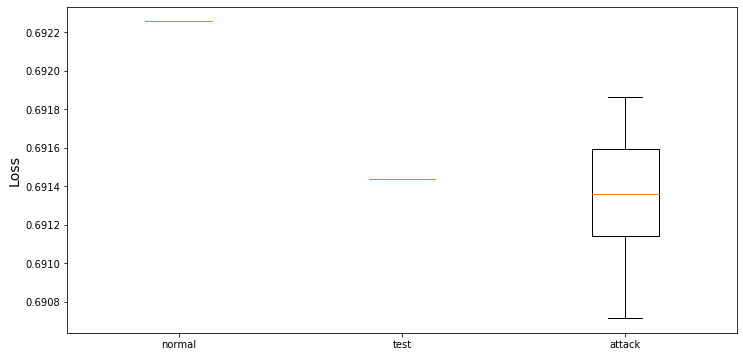

In [68]:
fig,ax = plt.subplots(figsize=(12,6))
ax.boxplot([a,list(t),list(b)],showfliers = True);
ax.set_xticklabels(['normal','test','attack']);
ax.set_ylabel('Loss',fontsize=14);

In [59]:
path = 'Models/documentation/fuz/conv/ssim/6'
save(path,[a,b,c,d],names=['normal','attack','disable','end'])

In [60]:
cbs.save_all(path,model=m,learn=learn,opt=opt)